# 03 - Classificazione binaria

Questo notebook usa le feature estratte nel notebook precedente per classificare:

```text
stress vs non-stress
```

La validazione usa `LeaveOneGroupOut`, dove il gruppo e' il soggetto. In questo modo il modello viene testato su soggetti non visti durante il training.


## 1. Import delle librerie


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


## 2. Caricamento del dataset di feature


In [2]:
def find_features_path():
    candidates = [
        Path("/kaggle/working/data/processed/features_chest.csv"),
        Path("data/processed/features_chest.csv"),
        Path("../data/processed/features_chest.csv"),
        Path("/kaggle/input/datasets/itsvise/features-chest/features_chest.csv"),
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError("features_chest.csv non trovato. Eseguire prima il notebook 02-feature-extraction.ipynb.")


FEATURES_PATH = find_features_path()
features = pd.read_csv(FEATURES_PATH)

print("File caricato:", FEATURES_PATH)
print("Shape:", features.shape)
features.head()


File caricato: /kaggle/input/datasets/itsvise/features-chest/features_chest.csv
Shape: (526, 39)


,subject,start_idx,end_idx,start_seconds,end_seconds,label,label_name,binary_label,label_fraction,ECG_mean,...,Resp_min,Resp_max,Resp_range,Resp_median,Temp_mean,Temp_std,Temp_min,Temp_max,Temp_range,Temp_median
0,S2,210000,252000,300.0,360.0,1,baseline,non-stress,0.890881,0.001466,...,-5.550925,4.511106,10.062031,-0.086697,29.167694,0.060271,29.011780,29.426208,0.414429,29.158386
1,S2,252000,294000,360.0,420.0,1,baseline,non-stress,1.000000,0.000986,...,-1.391944,1.702889,3.094832,0.006293,28.885604,0.081293,28.727814,29.207275,0.479462,28.876862
2,S2,294000,336000,420.0,480.0,1,baseline,non-stress,1.000000,0.001455,...,-4.359904,2.069612,6.429516,0.048712,28.798114,0.037777,28.679108,28.988800,0.309692,28.793732
3,S2,336000,378000,480.0,540.0,1,baseline,non-stress,1.000000,0.001022,...,-1.527553,1.812610,3.340163,-0.008351,28.753808,0.063520,28.584656,29.023285,0.438629,28.736389
4,S2,378000,420000,540.0,600.0,1,baseline,non-stress,1.000000,0.001122,...,-1.513284,1.430502,2.943786,-0.005847,28.573873,0.041704,28.447449,28.820953,0.373505,28.561768


## 3. Preparazione di X, y e gruppi


In [3]:
metadata_columns = {
    "subject",
    "start_idx",
    "end_idx",
    "start_seconds",
    "end_seconds",
    "label",
    "label_name",
    "binary_label",
    "label_fraction",
}

feature_columns = [col for col in features.columns if col not in metadata_columns]

X = features[feature_columns]
y = (features["binary_label"] == "stress").astype(int)
groups = features["subject"]

print("Numero feature:", len(feature_columns))
print("Classi binarie:")
print(features["binary_label"].value_counts())
print("\nSoggetti:", sorted(groups.unique()))


Numero feature: 30
Classi binarie:
binary_label
non-stress    369
stress        157
Name: count, dtype: int64

Soggetti: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


## 4. Modelli da confrontare


In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
}

models.keys()


dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'kNN'])

## 5. Validazione leave-one-subject-out


In [5]:
def evaluate_model(model, X, y, groups):
    logo = LeaveOneGroupOut()
    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    metrics = {
        "accuracy": accuracy_score(y_true_all, y_pred_all),
        "precision_stress": precision_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
        "recall_stress": recall_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
        "f1_stress": f1_score(y_true_all, y_pred_all, pos_label=1, zero_division=0),
    }

    return metrics, y_true_all, y_pred_all


## 6. Addestramento e risultati


In [6]:
results = []
predictions = {}

for model_name, model in models.items():
    print("Valuto", model_name)
    metrics, y_true, y_pred = evaluate_model(model, X, y, groups)
    results.append({"model": model_name, **metrics})
    predictions[model_name] = (y_true, y_pred)

results_df = pd.DataFrame(results).sort_values("f1_stress", ascending=False)
results_df


Valuto Logistic Regression
Valuto Decision Tree
Valuto Random Forest
Valuto kNN


,model,accuracy,precision_stress,recall_stress,f1_stress
2,Random Forest,0.866920,0.878261,0.643312,0.742647
0,Logistic Regression,0.792776,0.623711,0.770701,0.689459
1,Decision Tree,0.807985,0.705882,0.611465,0.655290
3,kNN,0.819392,0.878049,0.458599,0.602510


## 7. Confusion matrix del modello migliore


Miglior modello: Random Forest
              precision    recall  f1-score   support

  non-stress       0.86      0.96      0.91       369
      stress       0.88      0.64      0.74       157

    accuracy                           0.87       526
   macro avg       0.87      0.80      0.83       526
weighted avg       0.87      0.87      0.86       526



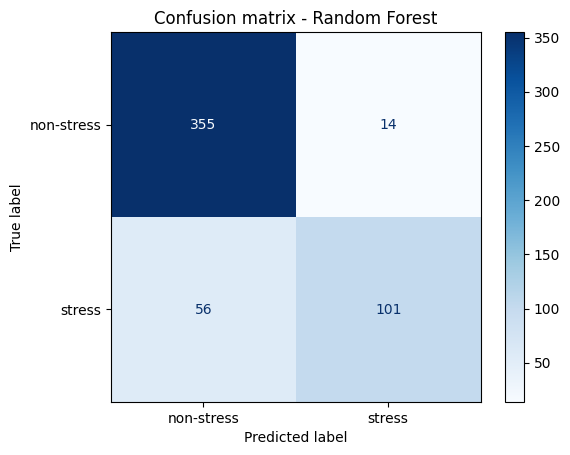

In [7]:
best_model_name = results_df.iloc[0]["model"]
y_true, y_pred = predictions[best_model_name]

print("Miglior modello:", best_model_name)
print(classification_report(y_true, y_pred, target_names=["non-stress", "stress"], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-stress", "stress"])
display.plot(cmap="Blues")
plt.title(f"Confusion matrix - {best_model_name}")
plt.show()


## 8. Performance per soggetto del modello migliore


In [8]:
def evaluate_best_model_by_subject(model, X, y, groups):
    logo = LeaveOneGroupOut()
    rows = []

    for train_idx, test_idx in logo.split(X, y, groups):
        test_subject = groups.iloc[test_idx].iloc[0]
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model),
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        rows.append({
            "subject": test_subject,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_stress": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
            "recall_stress": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
            "f1_stress": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "n_windows": len(y_test),
        })

    return pd.DataFrame(rows)


best_model = models[best_model_name]
subject_results = evaluate_best_model_by_subject(best_model, X, y, groups)
subject_results.sort_values("subject")


,subject,accuracy,precision_stress,recall_stress,f1_stress,n_windows
0,S10,0.685714,0.000000,0.000000,0.000000,35
1,S11,0.914286,1.000000,0.727273,0.842105,35
2,S13,0.914286,0.888889,0.800000,0.842105,35
3,S14,0.944444,1.000000,0.818182,0.900000,36
4,S15,0.805556,1.000000,0.363636,0.533333,36
5,S16,0.972222,1.000000,0.909091,0.952381,36
6,S17,0.944444,0.909091,0.909091,0.909091,36
7,S2,0.647059,0.000000,0.000000,0.000000,34
8,S3,0.911765,1.000000,0.700000,0.823529,34
9,S4,0.764706,1.000000,0.200000,0.333333,34
